# Question Hierarchy Analysis - Orchestration Notebook

This notebook orchestrates the analysis by calling standalone Python scripts that run in separate processes.
This avoids Jupyter's multiprocessing issues while still enabling parallel computation.

## Analysis Methods

1. **Mutual Information**: Questions with high MI with many others are fundamental
2. **Predictive Power**: Questions that predict many others well are fundamental (SLOW - run via sbatch)
3. **Network Centrality**: Questions central in the correlation network (using geodesic betweenness)
4. **Dimensionality Reduction**: Questions loading heavily on top PCs capture core variation
5. **Tree Structure (Chow-Liu)**: Questions near the root of the optimal tree are fundamental

## Running the Analysis

**Option 1: Run via sbatch (recommended for full analysis)**
```bash
sbatch run_analysis.sbatch       # Full analysis (all 5 methods)
sbatch run_predictive.sbatch     # Just predictive power (slowest)
```

**Option 2: Run from this notebook (faster methods only)**
Use the cells below to run individual analyses.

## Data Filtering

Only questions appearing in at least 2 of 3 years (2021, 2022, 2024) are included.

In [1]:
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuration
N_JOBS = 14  # Number of parallel workers
OUTPUT_DIR = 'results'
MIN_YEARS = 2  # Minimum years a question must appear in

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

## Run All Analyses

This runs all 5 analysis methods in a single subprocess. Results are saved to CSV files.

In [2]:
%%time
# Option A: Run ALL analyses (including slow predictive power)
# Uncomment the block below if you want to run everything from the notebook
# (This can take 30+ minutes due to predictive power)

"""
cmd = [
    'python', 'scripts/run_all_analyses.py',
    '--n_jobs', str(N_JOBS),
    '--output_dir', OUTPUT_DIR,
    '--min_years', str(MIN_YEARS)
]
print(f"Running: {' '.join(cmd)}")
result = subprocess.run(cmd, capture_output=False, text=True)
"""

# Option B: Run FAST analyses only (skip predictive power)
# This typically completes in 2-5 minutes
print("Running fast analyses (MI, Network, Dimensionality, Tree)...")
print("=" * 60)

for script, prefix in [
    ('run_mutual_information.py', 'mi'),
    ('run_network_centrality.py', 'network'),
    ('run_dimensionality.py', 'dimensionality'),
    ('run_tree_structure.py', 'tree'),
]:
    print(f"\n>>> Running {script}...")
    cmd = [
        'python', f'scripts/{script}',
        '--output_prefix', f'{OUTPUT_DIR}/{prefix}',
        '--min_years', str(MIN_YEARS),
    ]
    if 'n_jobs' in open(f'scripts/{script}').read():
        cmd.extend(['--n_jobs', str(N_JOBS)])
    
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"Error: {result.stderr[:500]}")
    else:
        print(f"Done: {prefix}")

print("\n" + "=" * 60)
print("Fast analyses complete!")
print(f"For predictive power, run: sbatch run_predictive.sbatch")

Running fast analyses (MI, Network, Dimensionality, Tree)...

>>> Running run_mutual_information.py...
Done: mi

>>> Running run_network_centrality.py...
Done: network

>>> Running run_dimensionality.py...
Done: dimensionality

>>> Running run_tree_structure.py...
Done: tree

Fast analyses complete!
For predictive power, run: sbatch run_predictive.sbatch
CPU times: user 5.29 ms, sys: 2.02 ms, total: 7.31 ms
Wall time: 55.8 s


In [3]:
# Combine results from individual analyses into unified ranking
import glob

print("Combining results...")

# Load all score files
score_files = {
    'MI': f'{OUTPUT_DIR}/mi_scores.csv',
    'Network': f'{OUTPUT_DIR}/network_scores.csv', 
    'Dimensionality': f'{OUTPUT_DIR}/dimensionality_scores.csv',
    'Tree': f'{OUTPUT_DIR}/tree_scores.csv',
    'Predictive': f'{OUTPUT_DIR}/predictive_scores.csv',  # May not exist
}

composite_scores = None
for method, filepath in score_files.items():
    try:
        scores = pd.read_csv(filepath, index_col=0)
        composite_col = [c for c in scores.columns if 'composite' in c.lower()]
        if composite_col:
            if composite_scores is None:
                composite_scores = pd.DataFrame(index=scores.index)
            composite_scores[method] = scores[composite_col[0]]
            print(f"  Loaded {method}")
    except FileNotFoundError:
        print(f"  {method}: not found (skipped)")

if composite_scores is not None:
    # Fill NaN with 0 and compute rankings
    composite_scores = composite_scores.fillna(0)
    
    method_cols = [c for c in composite_scores.columns]
    ranks = composite_scores[method_cols].rank(ascending=False)
    composite_scores['avg_rank'] = ranks.mean(axis=1)
    composite_scores['rank_std'] = ranks.std(axis=1)
    
    # Ensemble score
    normalized = composite_scores[method_cols].apply(
        lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else 0
    )
    composite_scores['ensemble_score'] = normalized.mean(axis=1)
    
    # Tier assignment
    composite_scores['tier'] = pd.cut(
        composite_scores['ensemble_score'],
        bins=[0, 0.3, 0.5, 0.7, 1.0],
        labels=['Tier 4 (Specific)', 'Tier 3', 'Tier 2', 'Tier 1 (Fundamental)']
    )
    
    composite_scores = composite_scores.sort_values('ensemble_score', ascending=False)
    composite_scores.to_csv(f'{OUTPUT_DIR}/combined_hierarchy.csv')
    print(f"\nSaved combined hierarchy to {OUTPUT_DIR}/combined_hierarchy.csv")

Combining results...
  Loaded MI
  Loaded Network
  Loaded Dimensionality
  Loaded Tree
  Predictive: not found (skipped)

Saved combined hierarchy to results/combined_hierarchy.csv


## Load Results

In [4]:
# Load combined hierarchy
combined = pd.read_csv(f'{OUTPUT_DIR}/combined_hierarchy.csv', index_col=0)

print(f"Loaded results for {len(combined)} questions")
print(f"\nColumns: {list(combined.columns)}")

Loaded results for 98 questions

Columns: ['MI', 'Network', 'Dimensionality', 'Tree', 'avg_rank', 'rank_std', 'ensemble_score', 'tier']


In [5]:
# Load individual method scores (handle missing predictive results)
mi_scores = pd.read_csv(f'{OUTPUT_DIR}/mi_scores.csv', index_col=0)
net_scores = pd.read_csv(f'{OUTPUT_DIR}/network_scores.csv', index_col=0)
dim_scores = pd.read_csv(f'{OUTPUT_DIR}/dimensionality_scores.csv', index_col=0)
tree_scores = pd.read_csv(f'{OUTPUT_DIR}/tree_scores.csv', index_col=0)

# Predictive power may not be available (it's slow)
try:
    pred_scores = pd.read_csv(f'{OUTPUT_DIR}/predictive_scores.csv', index_col=0)
    print("Loaded all individual method scores including predictive power.")
except FileNotFoundError:
    pred_scores = None
    print("Loaded individual method scores (predictive power not available).")
    print("To run predictive power: sbatch run_predictive.sbatch")

Loaded individual method scores (predictive power not available).
To run predictive power: sbatch run_predictive.sbatch


## Combined Rankings

In [6]:
# Display top 20 most fundamental questions
print("Top 20 Most Fundamental Questions:")
print("=" * 80)

display_cols = ['ensemble_score', 'avg_rank', 'rank_std', 'tier']
method_cols = [c for c in combined.columns if c not in display_cols + ['tier']]

combined[display_cols].head(20)

Top 20 Most Fundamental Questions:


,ensemble_score,avg_rank,rank_std,tier
helpblk,0.917429,5.75,8.220908,Tier 1 (Fundamental)
polviews,0.842676,6.75,6.500000,Tier 1 (Fundamental)
helppoor,0.793658,7.75,4.272002,Tier 1 (Fundamental)
natrace,0.782866,11.75,8.180261,Tier 1 (Fundamental)
eqwlth,0.768459,8.50,5.066228,Tier 1 (Fundamental)
abnomore,0.729109,7.25,3.862210,Tier 1 (Fundamental)
absingle,0.725720,8.00,2.828427,Tier 1 (Fundamental)
marasian,0.688226,23.50,30.924640,Tier 2
wrkwayup,0.685946,13.50,10.847427,Tier 2
marblk,0.684234,21.50,28.850188,Tier 2


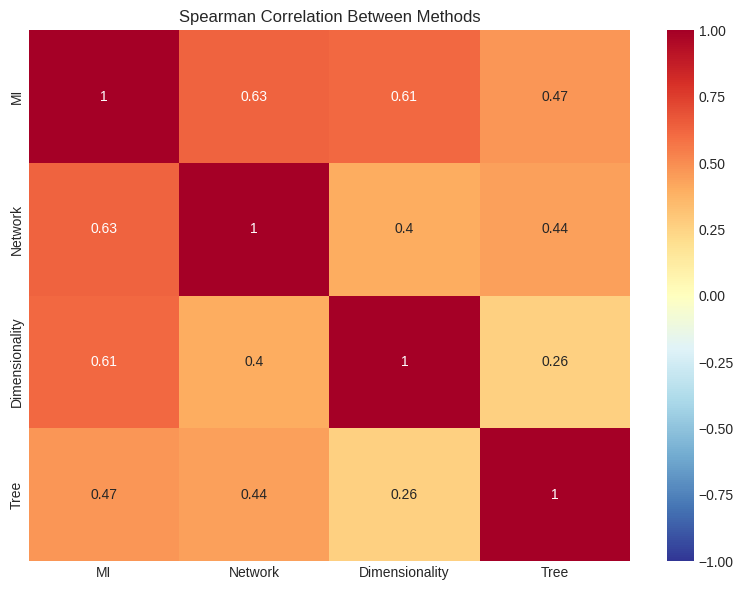


Method Agreement (Spearman correlations):
                   MI  Network  Dimensionality   Tree
MI              1.000    0.626           0.609  0.471
Network         0.626    1.000           0.401  0.439
Dimensionality  0.609    0.401           1.000  0.263
Tree            0.471    0.439           0.263  1.000


In [7]:
# Method agreement analysis
method_cols = ['MI', 'Predictive', 'Network', 'Dimensionality', 'Tree']
method_cols = [c for c in method_cols if c in combined.columns]

method_corr = combined[method_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(method_corr, annot=True, cmap='RdYlBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Spearman Correlation Between Methods')
plt.tight_layout()
plt.show()

print("\nMethod Agreement (Spearman correlations):")
print(method_corr.round(3))

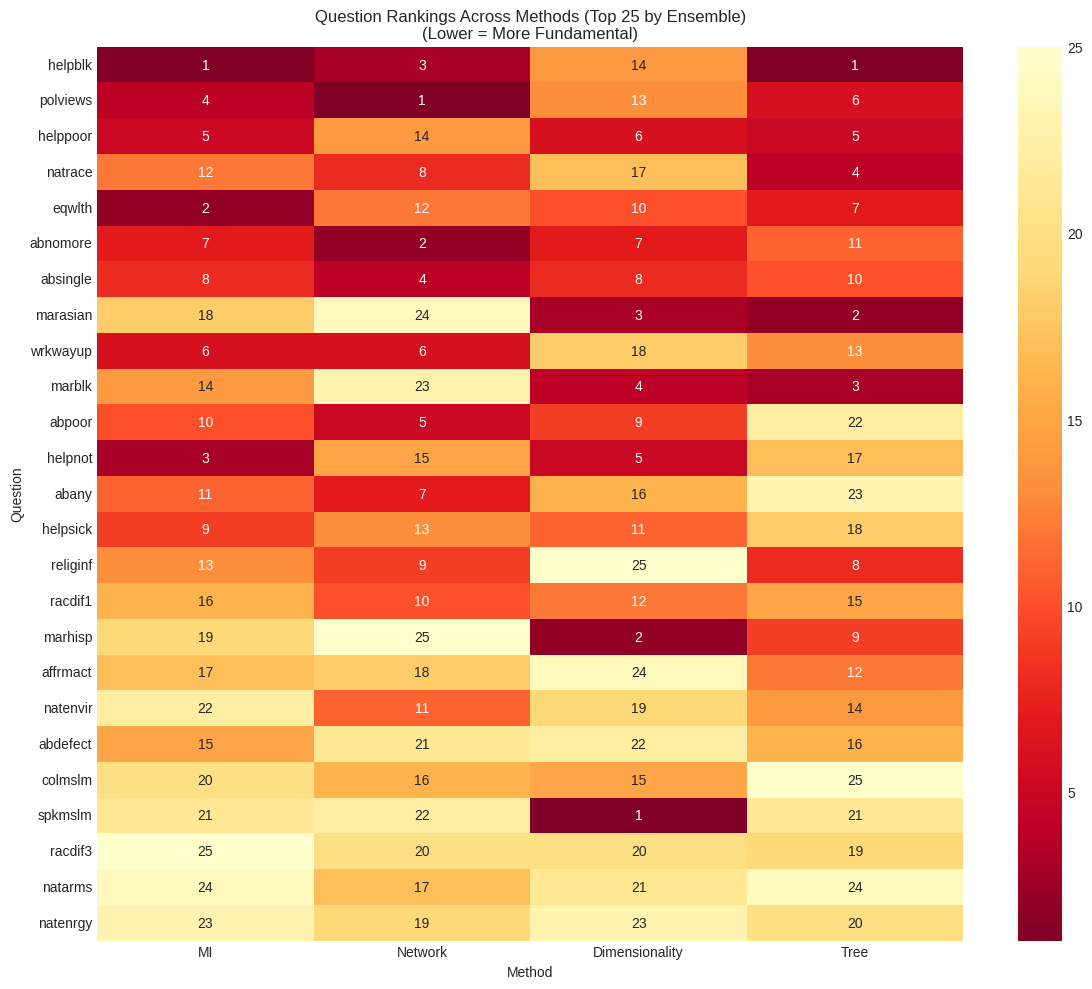

In [8]:
# Ranking heatmap for top questions
fig, ax = plt.subplots(figsize=(12, 10))

# Get top 25 questions
top_questions = combined.head(25).index.tolist()

# Create rank matrix
rank_matrix = combined.loc[top_questions, method_cols].rank(ascending=False)

sns.heatmap(rank_matrix, annot=True, fmt='.0f', cmap='YlOrRd_r', ax=ax)
ax.set_title('Question Rankings Across Methods (Top 25 by Ensemble)\n(Lower = More Fundamental)')
ax.set_xlabel('Method')
ax.set_ylabel('Question')
plt.tight_layout()
plt.show()

## Questions by Tier

Questions by Tier:
tier
Tier 3                  51
Tier 4 (Specific)       24
Tier 2                  16
Tier 1 (Fundamental)     7
Name: count, dtype: int64


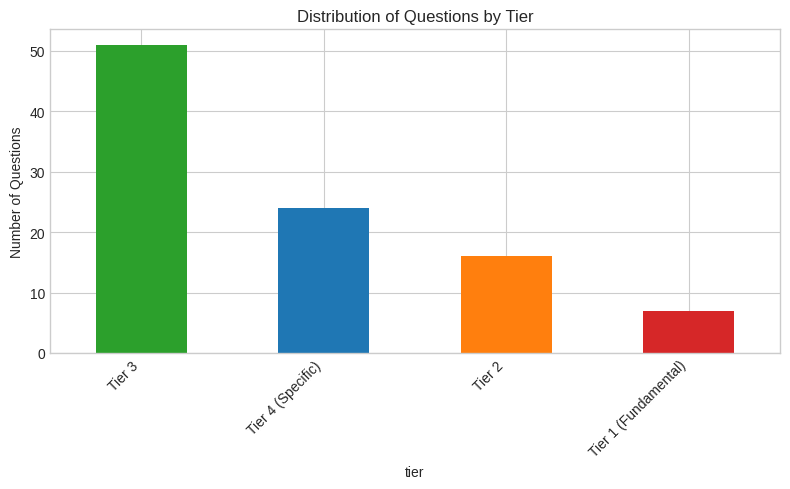

In [9]:
# Distribution by tier
tier_counts = combined['tier'].value_counts()
print("Questions by Tier:")
print(tier_counts)

fig, ax = plt.subplots(figsize=(8, 5))
tier_colors = {
    'Tier 1 (Fundamental)': '#d62728',
    'Tier 2': '#ff7f0e',
    'Tier 3': '#2ca02c',
    'Tier 4 (Specific)': '#1f77b4'
}
colors = [tier_colors.get(t, 'gray') for t in tier_counts.index]
tier_counts.plot(kind='bar', color=colors, ax=ax)
ax.set_ylabel('Number of Questions')
ax.set_title('Distribution of Questions by Tier')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
# List questions by tier
for tier in ['Tier 1 (Fundamental)', 'Tier 2', 'Tier 3', 'Tier 4 (Specific)']:
    tier_qs = combined[combined['tier'] == tier].index.tolist()
    if tier_qs:
        print(f"\n{tier} ({len(tier_qs)} questions):")
        print(f"  {', '.join(tier_qs[:20])}")
        if len(tier_qs) > 20:
            print(f"  ... and {len(tier_qs) - 20} more")


Tier 1 (Fundamental) (7 questions):
  helpblk, polviews, helppoor, natrace, eqwlth, abnomore, absingle

Tier 2 (16 questions):
  marasian, wrkwayup, marblk, abpoor, helpnot, abany, helpsick, religinf, racdif1, marhisp, affrmact, natenvir, abdefect, colmslm, spkmslm, racdif3

Tier 3 (51 questions):
  natarms, natenrgy, abrape, fehire, fejobaff, natfare, libcom, spkrac, marwht, spkcom, colath, natcity, natchld, confed, conclerg, libmslm, colrac, consci, spkmslmy, libath
  ... and 31 more

Tier 4 (Specific) (24 questions):
  wlthwhts, workwhts, getaheadnv, gunlaw, scienthe, sexeduc, intlwhts, libathy, natsoc, prayer, polmurdr, natpark, helpfulnv, grass, discaffw, natroad, courts, natspac, polabuse, racopen
  ... and 4 more


## Network Analysis Details

In [11]:
# Load network-specific results
geodesic = pd.read_csv(f'{OUTPUT_DIR}/network_geodesic_matrix.csv', index_col=0)
corr_matrix = pd.read_csv(f'{OUTPUT_DIR}/network_correlation_matrix.csv', index_col=0)

print("Network Statistics:")
try:
    net_stats = pd.read_csv(f'{OUTPUT_DIR}/network_network_stats.csv', index_col=0)
    for idx in net_stats.index:
        print(f"  {idx}: {net_stats.loc[idx, 'value']}")
except:
    print("  (stats not available)")

Network Statistics:
  n_nodes: 98
  n_edges: 4753
  density: 1.0
  is_connected: True
  avg_clustering: 0.10265076015767931
  avg_shortest_path: 0.8773248734172048
  diameter: 0.999972258498499


In [12]:
# Betweenness centrality (geodesic-based)
print("\nTop 15 by Geodesic Betweenness Centrality:")
print("(Measures how often a question lies on shortest paths between other questions)")
print()
print(net_scores[['betweenness_centrality', 'closeness_centrality', 'avg_geodesic_distance']].head(15))


Top 15 by Geodesic Betweenness Centrality:
(Measures how often a question lies on shortest paths between other questions)

          betweenness_centrality  closeness_centrality  avg_geodesic_distance
polviews                     0.0              1.287574               0.768730
abnomore                     0.0              1.248346               0.792886
helpblk                      0.0              1.253824               0.789422
absingle                     0.0              1.242910               0.796354
abpoor                       0.0              1.235557               0.801093
wrkwayup                     0.0              1.247286               0.793560
abany                        0.0              1.236667               0.800374
natrace                      0.0              1.245034               0.794995
religinf                     0.0              1.242539               0.796591
racdif1                      0.0              1.240624               0.797821
natenvir          

## Visualize Final Hierarchy

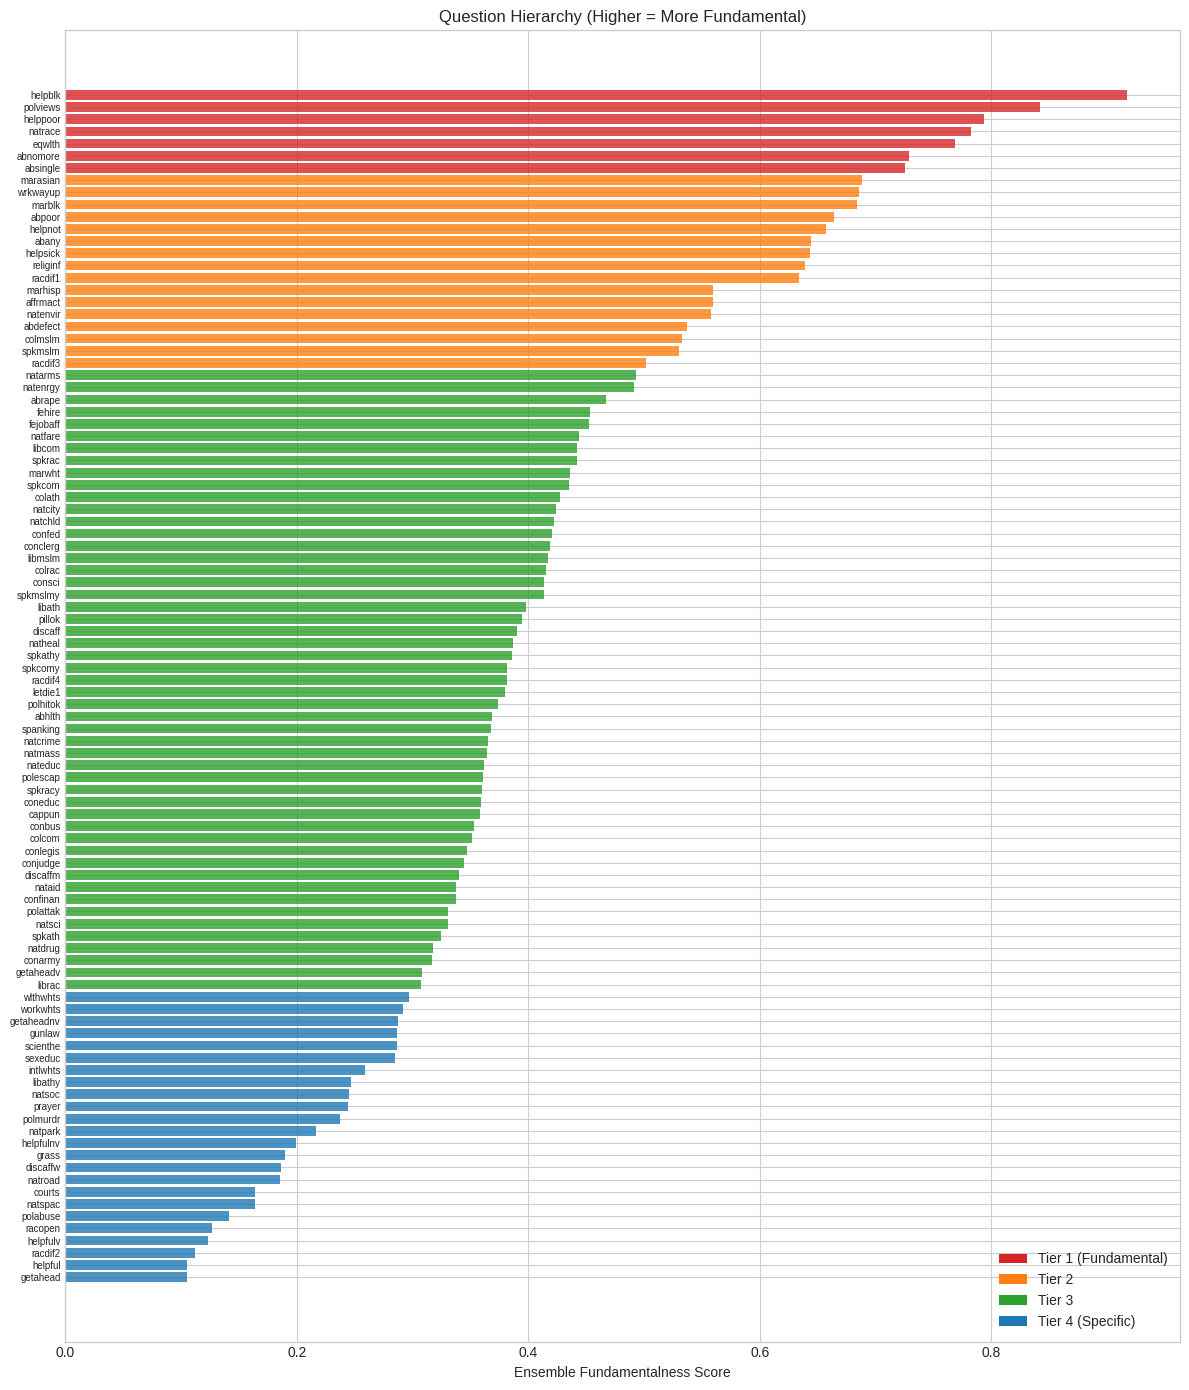

Saved visualization to results/question_hierarchy.png


In [13]:
# Bar chart of ensemble scores
fig, ax = plt.subplots(figsize=(12, 14))

plot_data = combined.sort_values('ensemble_score', ascending=True)

# Color by tier
tier_colors = {
    'Tier 1 (Fundamental)': '#d62728',
    'Tier 2': '#ff7f0e',
    'Tier 3': '#2ca02c',
    'Tier 4 (Specific)': '#1f77b4'
}
colors = [tier_colors.get(t, 'gray') for t in plot_data['tier']]

bars = ax.barh(range(len(plot_data)), plot_data['ensemble_score'], color=colors, alpha=0.8)
ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels(plot_data.index, fontsize=7)
ax.set_xlabel('Ensemble Fundamentalness Score')
ax.set_title('Question Hierarchy (Higher = More Fundamental)')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t) for t, c in tier_colors.items()]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/question_hierarchy.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved visualization to {OUTPUT_DIR}/question_hierarchy.png")

## Export Summary

In [14]:
# Create summary report
print("Summary Report")
print("=" * 60)
print(f"Total questions analyzed: {len(combined)}")
print(f"Questions in Tier 1 (Fundamental): {(combined['tier'] == 'Tier 1 (Fundamental)').sum()}")
print(f"Questions in Tier 2: {(combined['tier'] == 'Tier 2').sum()}")
print()
print("Top 10 Most Fundamental Questions:")
for i, q in enumerate(combined.head(10).index, 1):
    score = combined.loc[q, 'ensemble_score']
    print(f"  {i:2d}. {q:20s} (score: {score:.3f})")
print()
print(f"Results saved to: {OUTPUT_DIR}/")
print(f"  - combined_hierarchy.csv (unified ranking)")
print(f"  - question_hierarchy.png (visualization)")

Summary Report
Total questions analyzed: 98
Questions in Tier 1 (Fundamental): 7
Questions in Tier 2: 16

Top 10 Most Fundamental Questions:
   1. helpblk              (score: 0.917)
   2. polviews             (score: 0.843)
   3. helppoor             (score: 0.794)
   4. natrace              (score: 0.783)
   5. eqwlth               (score: 0.768)
   6. abnomore             (score: 0.729)
   7. absingle             (score: 0.726)
   8. marasian             (score: 0.688)
   9. wrkwayup             (score: 0.686)
  10. marblk               (score: 0.684)

Results saved to: results/
  - combined_hierarchy.csv (unified ranking)
  - question_hierarchy.png (visualization)
